# External Shock Transmission to Hong Kong Under the Currency Board: BVAR Evidence

**Model:** BVAR(4) | Minnesota prior, ML-optimized (Giannone, Lenza & Primiceri 2015) | pi1=0.085, pi2=1.0, pi3=1.0
**Sample:** 1998 Q1 – 2026 Q1 | 113 quarterly observations
**Ordering:** hibor → exports → property → gdp → cpi → unemployment (LERS-justified Cholesky)
**Exogenous:** us_ffr, china_gdp (contemporaneous only — VARX(4,0))

**Run order:** Cell 1 (imports) → Cell 2 (spec) → Cell 3 (estimation) → any downstream cell

| Section | Content |
|---|---|
| 1. Estimation | Single canonical BVAR — all results flow from here |
| 2. GDP Channels | Property→GDP FEVD 20.9% dominates; HIBOR hits GDP fast via property (h=1) and slow via direct credit (h=1–4) |
| 3. Stability | Welch & Levene on residuals. GDP stable across GFC and COVID; CPI shows a mean break at COVID (p=0.029) |
| 4. LP Robustness | Jordà (2005) HAC-robust IRFs on 4 channels — ordering-free confirmation |

## 0. Packages and Specification

In [14]:
# NumPy released version 2.0 and removed some old aliases: np.float_, np.complex_, np.int_. 
# The Alexandria library was written for the old NumPy, Python crashes.
# This patch adds the missing names back before Alexandria loads.

import numpy as _np_tmp
if not hasattr(_np_tmp, 'float_'):   _np_tmp.float_   = _np_tmp.float64
if not hasattr(_np_tmp, 'complex_'): _np_tmp.complex_ = _np_tmp.complex128
if not hasattr(_np_tmp, 'int_'):     _np_tmp.int_     = _np_tmp.int64
if not hasattr(_np_tmp, 'bool_'):    _np_tmp.bool_    = _np_tmp.bool_.__class__
del _np_tmp

import warnings; warnings.filterwarnings('ignore')
import numpy as np
np.random.seed(67)
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.regression.linear_model import OLS
from alexandria import MinnesotaBayesianVar
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf


#### FINAL SPEC optimized from supplementary analysis

In [15]:
# FINAL SPEC 
# Canonical endogenous ordering: HIBOR first, then exports, property price, GDP, CPI, and unemployment last.
ENDOG = ['hibor_3m', 'hk_exports_china_yoy', 'hk_property_price_qoq',
         'gdp_growth', 'cpi_inflation', 'unemployment']
EXOG  = ['us_ffr', 'china_gdp']
# After supplementary analysis, BVAR works best at lag 4 when accounting for seasonality and data frequency (quarterly data)
LAGS  = 4
PI1, PI2, PI3 = 0.085, 1.0, 1.0    # ML-optimized hyperparameters in explotation hyperparameter_optimization=True 
PI4   = 100.0                       # exogenous shrinkage: large = uninformative, optimizer used 99.75

# ML-optimal prior means (delta) optimized from hyperparameter_optimization=True (Empirical Bayes Priors)
# Order matches ENDOG: hibor, exports, prop, gdp, cpi, unemp
AR_COEF = [0.442, 0.627, 0.418, 0.545, 0.735, 0.991]
#           hibor  exp    prop   gdp    cpi    unemp
# hibor: mean-reverts under LERS peg
# prop:  fast-reverting asset price
# unemp: near random walk, slow adjustment
DATA = 'data/hk_macro_varx_ready.csv'

print('FINAL SPEC loaded.')
print(f'  ENDOG:   {ENDOG}')
print(f'  EXOG:    {EXOG}')
print(f'  LAGS:    {LAGS}')
print(f'  pi1={PI1}  pi2={PI2}  pi3={PI3}  pi4={PI4}')
print(f'  AR_COEF: {AR_COEF}')
print(f'           hibor  exp    prop  gdp   cpi   unemp')


FINAL SPEC loaded.
  ENDOG:   ['hibor_3m', 'hk_exports_china_yoy', 'hk_property_price_qoq', 'gdp_growth', 'cpi_inflation', 'unemployment']
  EXOG:    ['us_ffr', 'china_gdp']
  LAGS:    4
  pi1=0.085  pi2=1.0  pi3=1.0  pi4=100.0
  AR_COEF: [0.442, 0.627, 0.418, 0.545, 0.735, 0.991]
           hibor  exp    prop  gdp   cpi   unemp


## 1. Canonical BVAR Estimation

**Spec:** BVAR(4) | Minnesota prior | pi1, pi2, AR_COEF all ML-optimized via marginal likelihood (HK_BVAR_Exploration.ipynb)
**Ordering:** hibor → exports → property → gdp → cpi → unemployment
**T_eff:** 109 obs | k=27/eq | 90% posterior credibility bands

In [16]:
df = pd.read_csv(DATA, index_col=0, parse_dates=True)
Y  = df[ENDOG].values.astype(float)   # ENDOG = hibor-first ordering from FINAL SPEC
X  = df[EXOG].values.astype(float)
idx = {v: i for i, v in enumerate(ENDOG)}

bvar_canonical = MinnesotaBayesianVar(
    endogenous=Y, exogenous=X, lags=LAGS,
    pi1=PI1, pi2=PI2, pi3=PI3,
    ar_coefficients=AR_COEF,           # ML-optimal delta, hibor-first order
    iterations=2000, credibility_level=0.90, verbose=False
)
bvar_canonical.estimate()
print(f'Canonical BVAR(4) | T={bvar_canonical.T} | k={bvar_canonical.k}/eq')
print(f'pi1={PI1} pi2={PI2} pi3={PI3}')
print(f'AR_COEF={AR_COEF}')
print()

irf_can, exo_irf_can = bvar_canonical.impulse_response_function(h=9, credibility_level=0.90)
fevd_can   = bvar_canonical.forecast_error_variance_decomposition(h=8, credibility_level=0.90)

channels = [
    (idx['hibor_3m'], idx['hk_property_price_qoq'], 'hibor → property'),
    (idx['hk_exports_china_yoy'], idx['gdp_growth'], 'exports → gdp'),
    (idx['gdp_growth'], idx['cpi_inflation'],         'gdp → cpi'),
]

print('CANONICAL IRF (90% credibility bands):')
print(f'{"Channel":<22} {"h":>3}  Bands                   Sig?')
print('-' * 58)
for imp, resp, label in channels:
    for h in [1, 2, 4]:
        lo = irf_can[resp, imp, h, 1]; hi = irf_can[resp, imp, h, 2]
        sig = 'sig' if not (lo < 0 < hi) else 'x0'
        print(f'{label:<22} {h:>3}  ({lo:+.3f}, {hi:+.3f})  {sig}')
    print()

print('CANONICAL FEVD at h=8:')
print(f'  HIBOR share in property:  {fevd_can[idx["hk_property_price_qoq"],idx["hibor_3m"],7,0]*100:.0f}%')
print(f'  Exports share in GDP:     {fevd_can[idx["gdp_growth"],idx["hk_exports_china_yoy"],7,0]*100:.0f}%')
print(f'  HIBOR own-share:          {fevd_can[idx["hibor_3m"],idx["hibor_3m"],7,0]*100:.0f}%')
print(f'  GDP share in CPI:         {fevd_can[idx["cpi_inflation"],idx["gdp_growth"],7,0]*100:.0f}%')

Canonical BVAR(4) | T=109 | k=27/eq
pi1=0.085 pi2=1.0 pi3=1.0
AR_COEF=[0.442, 0.627, 0.418, 0.545, 0.735, 0.991]

CANONICAL IRF (90% credibility bands):
Channel                  h  Bands                   Sig?
----------------------------------------------------------
hibor → property         1  (-1.004, -0.343)  sig
hibor → property         2  (-0.507, +0.106)  x0
hibor → property         4  (-0.208, +0.074)  x0

exports → gdp            1  (+0.260, +0.528)  sig
exports → gdp            2  (+0.055, +0.372)  sig
exports → gdp            4  (-0.198, +0.111)  x0

gdp → cpi                1  (+0.075, +0.172)  sig
gdp → cpi                2  (+0.102, +0.229)  sig
gdp → cpi                4  (+0.114, +0.259)  sig

CANONICAL FEVD at h=8:
  HIBOR share in property:  12%
  Exports share in GDP:     16%
  HIBOR own-share:          94%
  GDP share in CPI:         10%


### Canonical IRF and FEVD

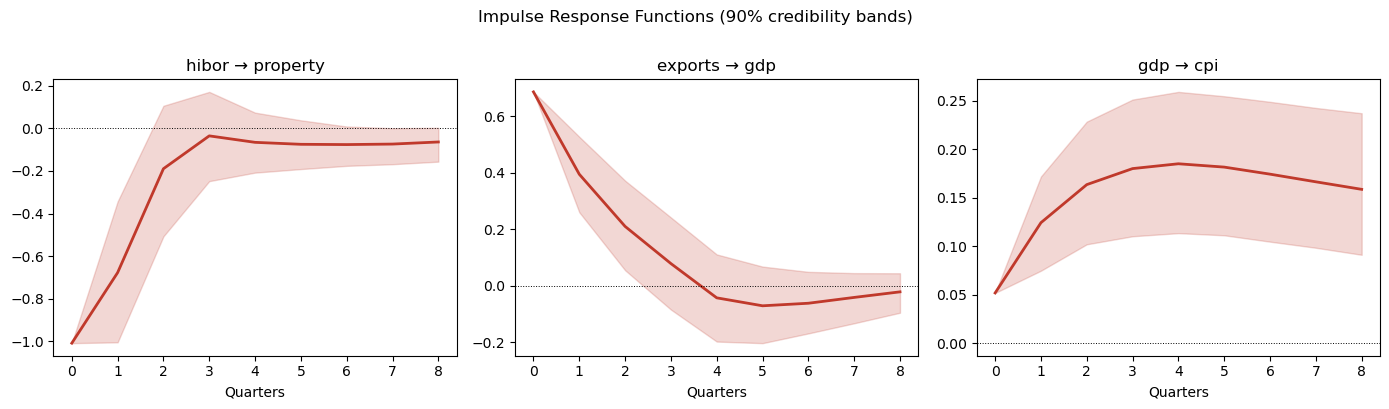

In [17]:
t = np.arange(9)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (imp, resp, title) in zip(axes, channels):
    ax.plot(t, irf_can[resp, imp, :, 0], color='#c0392b', lw=2)
    ax.fill_between(t, irf_can[resp, imp, :, 1], irf_can[resp, imp, :, 2], alpha=0.2, color='#c0392b')
    ax.axhline(0, color='k', lw=0.7, ls=':')
    ax.set_title(title)
    ax.set_xlabel('Quarters')
fig.suptitle('Impulse Response Functions (90% credibility bands)', y=1.01)
plt.tight_layout()
plt.savefig('output/phase9a_canonical_irf.png', dpi=150, bbox_inches='tight')
plt.show()

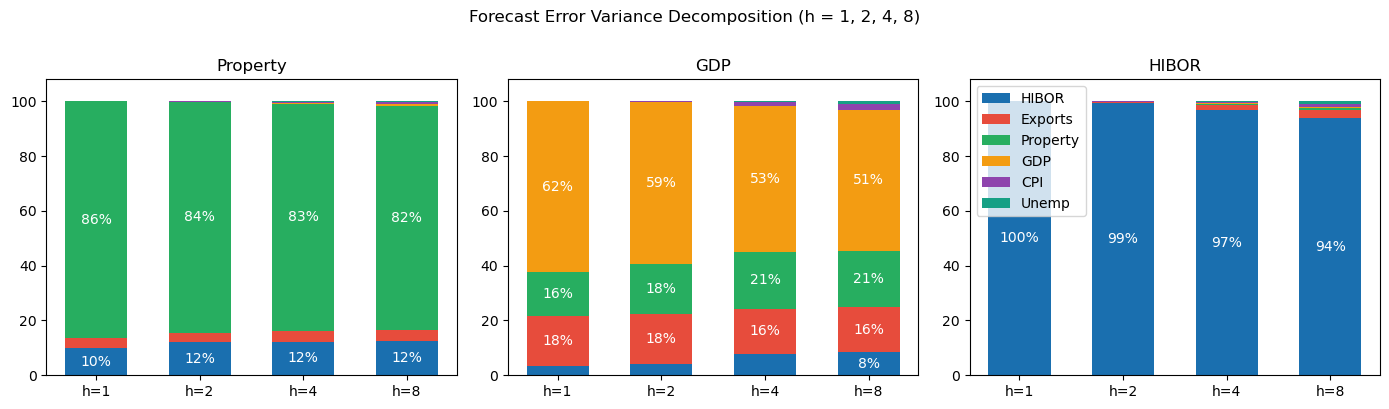

In [18]:
## FEVD plot
labels_short = ['HIBOR','Exports','Property','GDP','CPI','Unemp']
colors = ['#1a6faf','#e74c3c','#27ae60','#f39c12','#8e44ad','#16a085']
hs = [1, 2, 4, 8]
focus = [(idx['hk_property_price_qoq'],'Property'), (idx['gdp_growth'],'GDP'), (idx['hibor_3m'],'HIBOR')]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax_i, (ri, rname) in enumerate(focus):
    data = np.array([fevd_can[ri, :, h-1, 0]*100 for h in hs])
    bottom = np.zeros(len(hs))
    for ci, (color, sl) in enumerate(zip(colors, labels_short)):
        ax = axes[ax_i]
        ax.bar(range(len(hs)), data[:, ci], bottom=bottom, color=color, label=sl, width=0.6)
        for hi, (val, bot) in enumerate(zip(data[:, ci], bottom)):
            if val > 8: ax.text(hi, bot+val/2, f"{val:.0f}%", ha='center', va='center', color='white')
        bottom += data[:, ci]
    ax.set_title(rname)
    ax.set_xticks(range(len(hs))); ax.set_xticklabels([f'h={h}' for h in hs])
    ax.set_ylim(0, 108)
    if ax_i == 2: ax.legend(loc='upper left', framealpha=0.8)
fig.suptitle('Forecast Error Variance Decomposition (h = 1, 2, 4, 8)', y=1.01)
plt.tight_layout()
plt.savefig('output/phase9a_canonical_fevd.png', dpi=150, bbox_inches='tight')
plt.show()

### Exogenous Channel Quantification

End-to-end BVAR dynamic multiplier: response of all 6 endogenous variables to a 1pp shock in us_ffr or china_gdp, all transmission channels combined (via HIBOR, property, exports, and direct paths), full posterior.

In [19]:
# Exogenous dynamic multipliers — all endogenous responses to 1pp FFR and China GDP shock
ffr_i = EXOG.index('us_ffr')
chn_i = EXOG.index('china_gdp')
endog_short = ['HIBOR', 'Exports', 'Property', 'GDP', 'CPI', 'Unemp']

for exog_i, label in [(ffr_i, 'US FFR'), (chn_i, 'China GDP')]:
    rows = {v: [round(exo_irf_can[i, exog_i, h, 0], 3) for h in [1, 2, 4]]
            for i, v in enumerate(endog_short)}
    display(pd.DataFrame(rows, index=['h=1', 'h=2', 'h=4']).rename_axis(f'1pp {label} shock →'))

,HIBOR,Exports,Property,GDP,CPI,Unemp
1pp US FFR shock →,,,,,,
h=1,0.222,0.210,-0.322,0.224,0.067,-0.120
h=2,0.089,-0.194,-0.117,-0.024,0.065,-0.080
h=4,0.003,-0.351,0.012,-0.196,-0.007,-0.019


,HIBOR,Exports,Property,GDP,CPI,Unemp
1pp China GDP shock →,,,,,,
h=1,-0.016,0.571,0.117,0.219,0.086,-0.024
h=2,-0.011,0.343,0.020,0.131,0.088,-0.030
h=4,-0.007,-0.063,0.044,-0.004,0.082,-0.032


### Exogenous IRF: All Endogenous Responses

**FFR shock (top row): GDP goes up at h=1, then turns negative.**  
This is not a contradiction. At h=0–1, a US rate hike coincides with a US boom — HK exports and trade benefit contemporaneously. By h=2–4, the monetary tightening channel dominates: FFR rises → HIBOR rises (LERS) → property and credit contract → GDP falls. This sign reversal is common in open-economy reduced-form VARs when the shock proxy mixes the US expansion effect and the tightening effect. It reflects that FFR is a monetary *conditions* proxy, not a clean Romer-Romer policy surprise — the demand effect and the tightening effect both travel in the impulse.

**China GDP shock (bottom row): positive and fading.**  
+0.216pp at h=1, near zero by h=4. Cleaner story because China GDP does not have a competing tightening mechanism — a China boom lifts HK exports directly and decays as the impulse dissipates.

**HIBOR response to FFR (top-left panel):** confirms LERS transmission — FFR shock raises HIBOR immediately and persistently.

**Limitation:** FFR is not a structural monetary policy surprise. The contemporaneous positive GDP effect likely reflects the demand-side correlation between US rate hikes and the US expansion phase that triggered them.

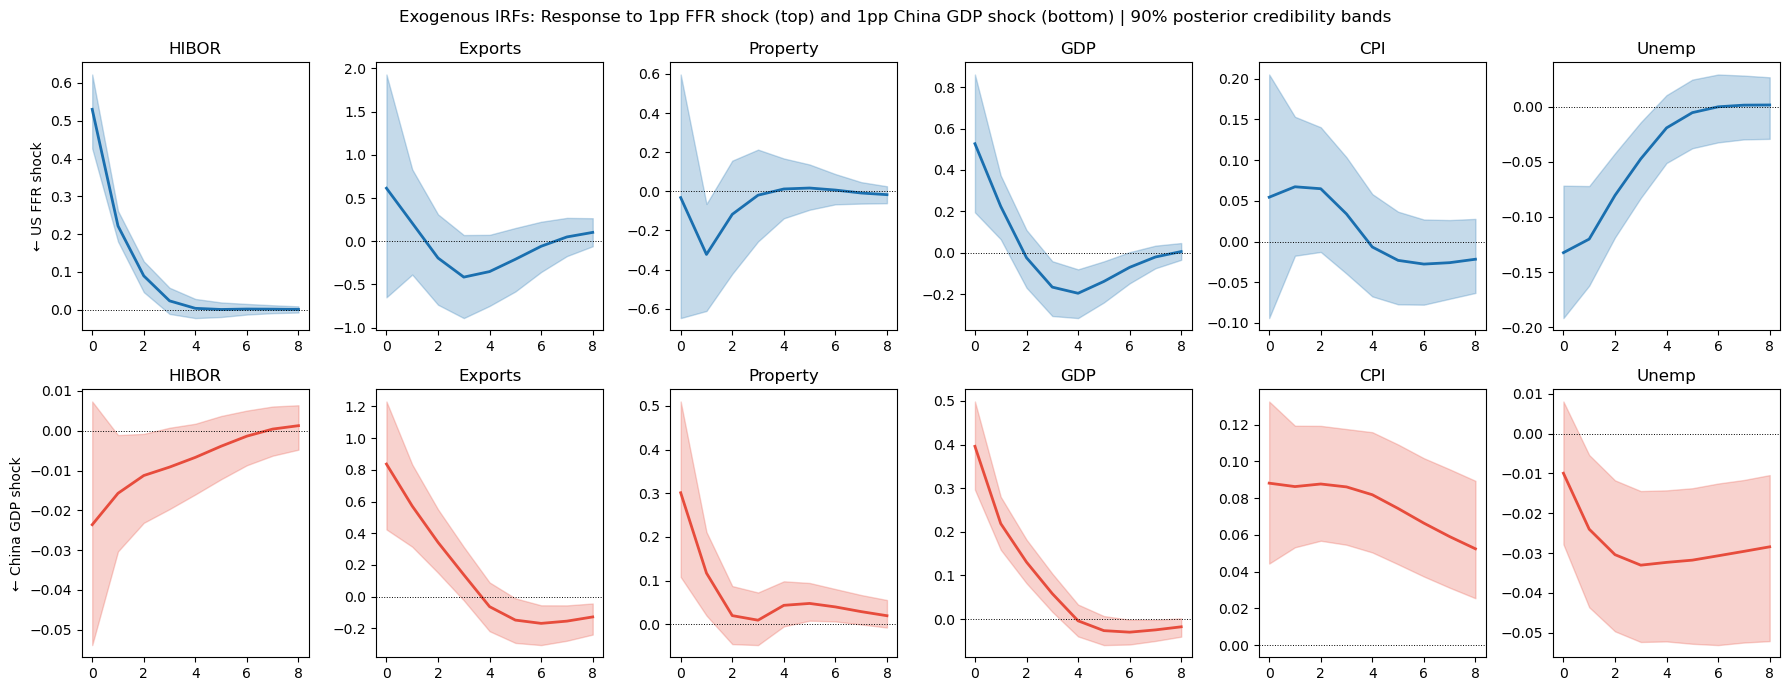

In [20]:
# Exogenous IRF plot: all 6 endogenous responses to FFR and China GDP, h=0..8
horizons = np.arange(9)
exog_labels = ['US FFR', 'China GDP']
endog_labels = ['HIBOR', 'Exports', 'Property', 'GDP', 'CPI', 'Unemp']
colors = ['#1a6faf', '#e74c3c']

fig, axes = plt.subplots(2, 6, figsize=(18, 7), sharey=False)

for exog_i, (exog_label, color) in enumerate(zip(exog_labels, colors)):
    for endog_i, endog_label in enumerate(endog_labels):
        ax = axes[exog_i, endog_i]
        med = exo_irf_can[endog_i, exog_i, :, 0]
        lo  = exo_irf_can[endog_i, exog_i, :, 1]
        hi  = exo_irf_can[endog_i, exog_i, :, 2]
        ax.fill_between(horizons, lo, hi, alpha=0.25, color=color)
        ax.plot(horizons, med, color=color, lw=2)
        ax.axhline(0, color='black', lw=0.7, ls=':')
        ax.set_title(endog_label)
        ax.set_xticks([0, 2, 4, 6, 8])
        if endog_i == 0:
            ax.set_ylabel(f'← {exog_label} shock')

fig.suptitle('Exogenous IRFs: Response to 1pp FFR shock (top) and 1pp China GDP shock (bottom) | 90% posterior credibility bands')
plt.tight_layout()
plt.savefig('output/exo_irf_all_responses.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. GDP Channel Decomposition

- Property explains 20.5% of GDP forecast-error variance at h=8.
- Exports explain 16.6%; HIBOR explains 8.7%.
- IRFs show the timing: HIBOR hits property at h=1; property raises GDP at h=1-2; HIBOR lowers GDP through h=4.

FEVD shares are Cholesky shares. HIBOR is ordered first, so its share captures variance driven by HIBOR shocks identified before property enters. Property's share captures independent property shocks orthogonal to HIBOR — not double-counting.

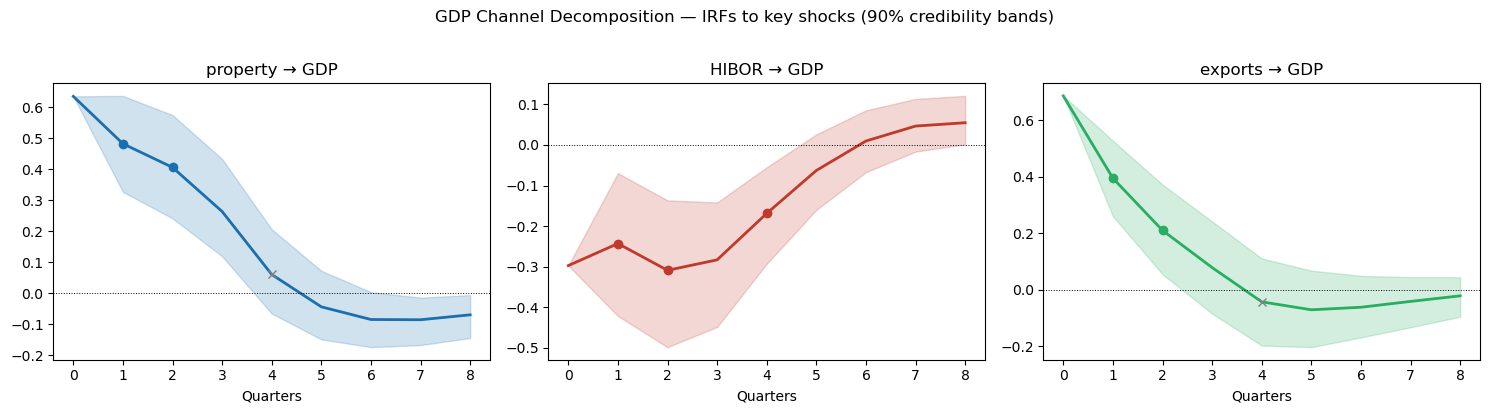

,channel,fevd_h8_pct
0,property→gdp,20.700547
1,exports→gdp,16.391437
2,hibor→gdp,8.439785


In [21]:
hibor_gdp_fevd_h8 = fevd_can[idx['gdp_growth'], idx['hibor_3m'], 7, 0] * 100
prop_gdp_fevd_h8  = fevd_can[idx['gdp_growth'], idx['hk_property_price_qoq'], 7, 0] * 100
exp_gdp_fevd_h8   = fevd_can[idx['gdp_growth'], idx['hk_exports_china_yoy'], 7, 0] * 100

t = np.arange(9)
channels_10a = [
    (idx['hk_property_price_qoq'], idx['gdp_growth'], 'property → GDP', '#1a6faf'),
    (idx['hibor_3m'],               idx['gdp_growth'], 'HIBOR → GDP',    '#c0392b'),
    (idx['hk_exports_china_yoy'],   idx['gdp_growth'], 'exports → GDP',  '#27ae60'),
]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (imp, resp, title, col) in zip(axes, channels_10a):
    med = irf_can[resp, imp, :, 0]
    lo  = irf_can[resp, imp, :, 1]
    hi  = irf_can[resp, imp, :, 2]
    ax.plot(t, med, color=col, lw=2)
    ax.fill_between(t, lo, hi, alpha=0.2, color=col)
    ax.axhline(0, color='k', lw=0.7, ls=':')
    ax.set_title(title)
    ax.set_xlabel('Quarters')
    for h in [1, 2, 4]:
        lo_h = irf_can[resp, imp, h, 1]; hi_h = irf_can[resp, imp, h, 2]
        marker = 'o' if not (lo_h < 0 < hi_h) else 'x'
        mc     = col if not (lo_h < 0 < hi_h) else 'grey'
        ax.plot(h, irf_can[resp, imp, h, 0], marker, color=mc, ms=6, zorder=5)
fig.suptitle('GDP Channel Decomposition — IRFs to key shocks (90% credibility bands)', y=1.02)
plt.tight_layout()
plt.savefig('output/phase10a_gdp_channels.png', dpi=150, bbox_inches='tight')
plt.show()

fevd_df = pd.DataFrame({
    'channel': ['property→gdp', 'exports→gdp', 'hibor→gdp'],
    'fevd_h8_pct': [prop_gdp_fevd_h8, exp_gdp_fevd_h8, hibor_gdp_fevd_h8]
})
fevd_df.to_csv('output/fevd_gdp_h8.csv', index=False)
display(fevd_df)

## 3. Structural Stability

Mean-break tests (Welch t-test) and variance-shift tests (Levene) on BVAR residuals at four candidate break dates.

| Equation | SARS 2003Q2 | China 2015Q3 | GFC 2008Q3 | COVID 2020Q1 |
|---|---|---|---|---|
| hibor | stable | stable | stable / **var shift** (p=0.035) | stable |
| exports | stable | stable | stable / **var shift** (p=0.003) | borderline (p=0.076) / **var shift** (p=0.029) |
| property | stable | stable | stable | stable |
| gdp | stable | stable | stable (p=0.144) | stable (p=0.278) |
| cpi | stable | stable | stable | **mean break** (p=0.033) |
| unemployment | stable | stable | stable | stable / **var shift** (p=0.003) |

Read: GDP has no mean break at GFC or COVID — the break visible under VARX(1) (p=0.006) disappears under BVAR(4). CPI has a COVID mean break (p=0.033). Variance shifts at GFC and COVID reflect large-shock episodes; the transmission architecture for GDP and property is stable.

In [22]:
# Mean-break (Welch t) & variance-shift (Levene) tests on BVAR(4) residuals
bvar_canonical.insample_fit()
resid = bvar_canonical.residual_estimates[:, :, 0]
T_eff = resid.shape[0]
dates = df.index[LAGS:]
resid_df = pd.DataFrame(resid, index=dates, columns=ENDOG)
print(f'Residuals: T_eff={T_eff}, {dates[0].date()} to {dates[-1].date()}')

def mean_var_test(series, break_date, dates):
    pre  = series[dates < pd.Timestamp(break_date)]
    post = series[dates >= pd.Timestamp(break_date)]
    if min(len(pre), len(post)) < 5: return np.nan, np.nan, np.nan, np.nan
    t_stat, t_p   = stats.ttest_ind(pre, post, equal_var=False)
    lev_stat, l_p = stats.levene(pre, post)
    return t_stat, t_p, lev_stat, l_p

breakpoints = [('SARS 2003Q2', '2003-04-01'), ('China 2015Q3', '2015-07-01'), ('GFC 2008Q3', '2008-07-01'), ('COVID 2020Q1', '2020-01-01')]
print('\nMean-break & Variance-shift Tests on BVAR(4) Residuals:')
print(f'{"Equation":<32} {"Break":>14}  {"Mean p":>8}  {"Mean verdict":>14}  {"Var p":>8}  {"Var verdict":>12}')
print('-' * 96)
for col in ENDOG:
    for bp_label, bp_date in breakpoints:
        t_s, t_p, l_s, l_p = mean_var_test(resid_df[col].values, bp_date, dates)
        if np.isnan(t_p):
            print(f'{col:<32} {bp_label:>14}  {"n/a":>8}  {"n/a":>14}  {"n/a":>8}')
            continue
        m_v = 'BREAK' if t_p < 0.05 else ('borderline' if t_p < 0.10 else 'stable')
        v_v = 'var shift' if l_p < 0.05 else 'stable'
        print(f'{col:<32} {bp_label:>14}  {t_p:>8.4f}  {m_v:>14}  {l_p:>8.4f}  {v_v:>12}')
    print()

Residuals: T_eff=109, 1999-01-01 to 2026-01-01

Mean-break & Variance-shift Tests on BVAR(4) Residuals:
Equation                                  Break    Mean p    Mean verdict     Var p   Var verdict
------------------------------------------------------------------------------------------------
hibor_3m                            SARS 2003Q2    0.1410          stable    0.5637        stable
hibor_3m                           China 2015Q3    0.4104          stable    0.8353        stable
hibor_3m                             GFC 2008Q3    0.9937          stable    0.0356     var shift
hibor_3m                           COVID 2020Q1    0.3057          stable    0.1232        stable

hk_exports_china_yoy                SARS 2003Q2    0.3792          stable    0.2245        stable
hk_exports_china_yoy               China 2015Q3    0.1428          stable    0.2160        stable
hk_exports_china_yoy                 GFC 2008Q3    0.1355          stable    0.0029     var shift
hk_exports_chi

## 4. Local Projection Robustness

LP-IRFs use HAC standard errors and 4 lags. Contemporaneous controls follow the BVAR ordering.

- HIBOR -> property: LP and BVAR both significant at h=1 only.
- HIBOR -> GDP: LP significant at h=1-3; BVAR remains significant at h=4.
- Property -> GDP: LP significant at h=1-3.
- Exports -> GDP: weaker in LP; direction is positive but less clean.

Use this as robustness for the channel timing, not as a replacement for the BVAR.


In [23]:
# Local Projection Robustness: Jordà (2005), HAC SEs
irf_bvar = irf_can

endog_arr = df[ENDOG].values.astype(float)
T         = len(df)
H_MAX     = 8
Z_90      = 1.645

def run_lp(shock_var, resp_var):
    shock_i     = idx[shock_var]
    resp_i      = idx[resp_var]
    k           = ENDOG.index(shock_var)
    contemp_idx = [idx[ENDOG[j]] for j in range(k)]
    exog_arr_lp = df[EXOG].values.astype(float)
    betas, lo_arr, hi_arr = [], [], []
    for h in range(H_MAX + 1):
        t_start = LAGS
        t_end   = T - h
        n       = t_end - t_start
        y          = endog_arr[t_start + h : t_end + h, resp_i]
        shock      = endog_arr[t_start:t_end, shock_i]
        ctrl_endog = np.hstack([endog_arr[t_start - lag : t_end - lag, :]
                                for lag in range(1, LAGS + 1)])
        ctrl_exog  = np.hstack([exog_arr_lp[t_start - lag : t_end - lag, :]
                                for lag in range(1, LAGS + 1)])
        parts = [np.ones((n, 1)), shock.reshape(-1, 1)]
        if contemp_idx:
            parts.append(endog_arr[t_start:t_end, contemp_idx].reshape(n, -1))
        parts.extend([ctrl_endog, ctrl_exog])
        X_lp = np.hstack(parts)
        bw   = max(h + 1, int(n ** (1/3)))
        res  = OLS(y, X_lp).fit(cov_type='HAC',
                                 cov_kwds={'maxlags': bw, 'use_correction': True})
        b  = res.params[1]
        se = res.bse[1]
        betas.append(b)
        lo_arr.append(b - Z_90 * se)
        hi_arr.append(b + Z_90 * se)
    return np.array(betas), np.array(lo_arr), np.array(hi_arr)

lp_channels = [
    ('hibor_3m',              'hk_property_price_qoq', 'HIBOR → Property', '#1a6faf'),
    ('hibor_3m',              'gdp_growth',             'HIBOR → GDP',      '#e74c3c'),
    ('hk_exports_china_yoy',  'gdp_growth',             'Exports → GDP',    '#27ae60'),
    ('hk_property_price_qoq', 'gdp_growth',             'Property → GDP',   '#f39c12'),
]

results = {}
for shock_var, resp_var, label, _ in lp_channels:
    betas, lo_arr, hi_arr = run_lp(shock_var, resp_var)
    results[label] = (betas, lo_arr, hi_arr)

rows = []
for shock_var, resp_var, label, _ in lp_channels:
    betas, lo_arr, hi_arr = results[label]
    imp_i  = idx[shock_var]; resp_i = idx[resp_var]
    for h in [1, 2, 3, 4]:
        lp_sig   = 'sig' if lo_arr[h] * hi_arr[h] > 0 else 'x0'
        bvar_sig = 'sig' if irf_bvar[resp_i, imp_i, h, 1] * irf_bvar[resp_i, imp_i, h, 2] > 0 else 'x0'
        rows.append({'Channel': label, 'h': h,
                     'LP β': round(betas[h], 3),
                     'LP lo': round(lo_arr[h], 3),
                     'LP hi': round(hi_arr[h], 3),
                     'LP sig': lp_sig, 'BVAR sig': bvar_sig})
display(pd.DataFrame(rows))


,Channel,h,LP β,LP lo,LP hi,LP sig,BVAR sig
0,HIBOR → Property,1,-3.194,-4.828,-1.560,sig,sig
1,HIBOR → Property,2,-0.908,-2.586,0.769,x0,x0
2,HIBOR → Property,3,0.771,-0.937,2.480,x0,x0
3,HIBOR → Property,4,-0.303,-1.618,1.012,x0,x0
4,HIBOR → GDP,1,-1.068,-1.972,-0.163,sig,sig
5,HIBOR → GDP,2,-1.466,-2.287,-0.645,sig,sig
6,HIBOR → GDP,3,-1.333,-2.354,-0.311,sig,sig
7,HIBOR → GDP,4,0.300,-0.730,1.331,x0,sig
8,Exports → GDP,1,0.049,-0.005,0.102,x0,sig
9,Exports → GDP,2,0.045,-0.013,0.102,x0,sig


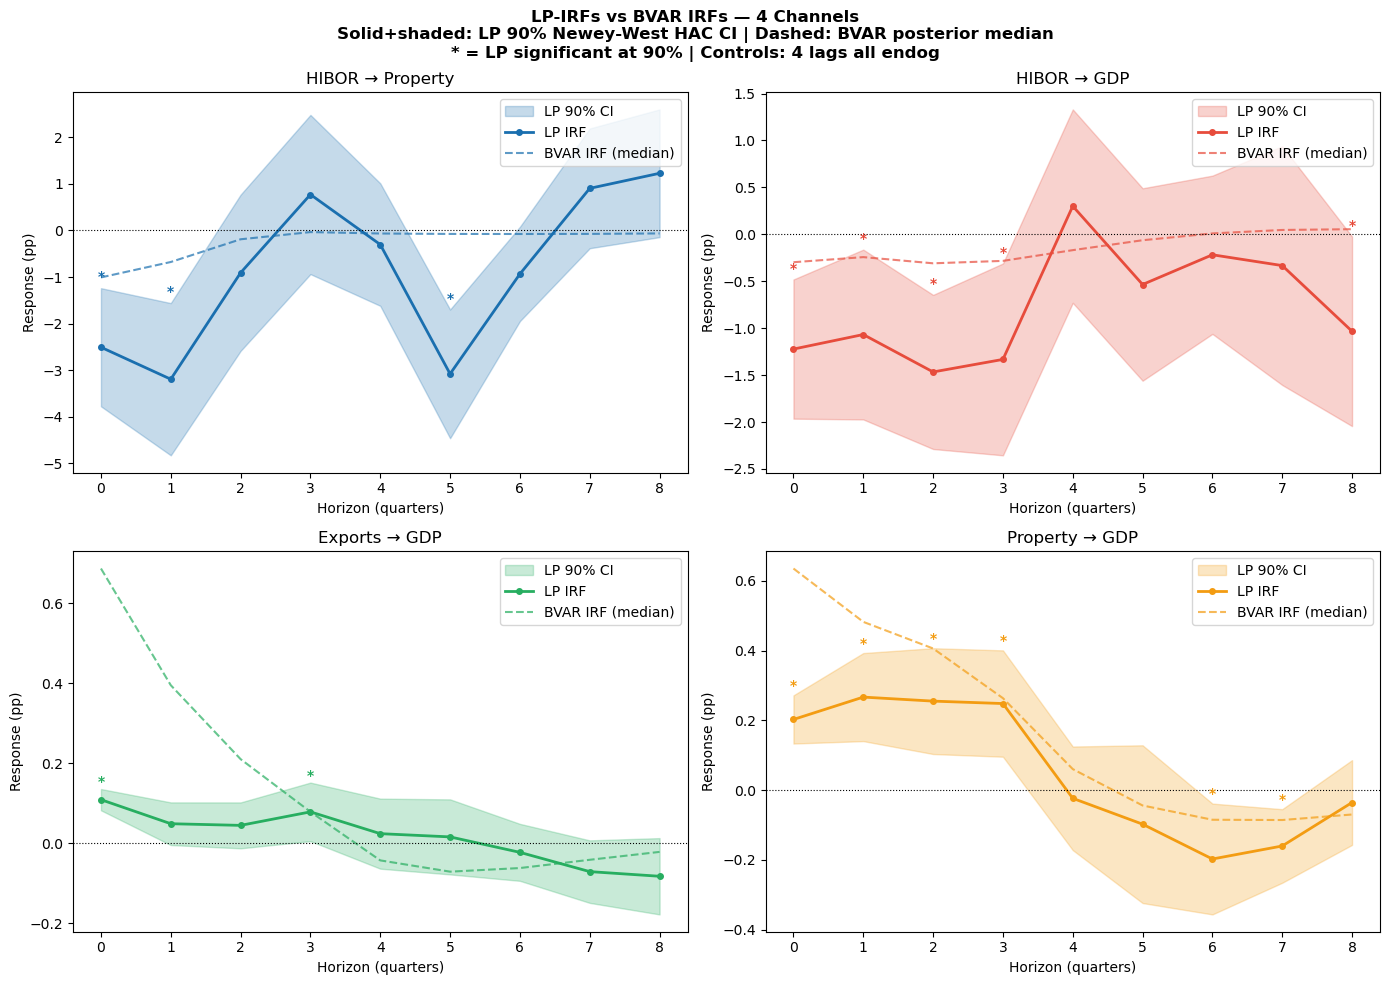

Saved: output/phase10b_lp_irf_4panel.png


In [24]:
# LP-IRF 4-panel figure
horizons = np.arange(H_MAX + 1)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (shock_var, resp_var, label, color) in zip(axes, lp_channels):
    betas, lo_arr, hi_arr = results[label]
    imp_i  = idx[shock_var]
    resp_i = idx[resp_var]

    ax.fill_between(horizons, lo_arr, hi_arr, alpha=0.25, color=color, label='LP 90% CI')
    ax.plot(horizons, betas, color=color, lw=2, marker='o', ms=4, label='LP IRF')
    ax.plot(horizons, irf_bvar[resp_i, imp_i, :, 0],
            color=color, lw=1.5, ls='--', alpha=0.7, label='BVAR IRF (median)')

    for h in range(H_MAX + 1):
        if lo_arr[h] * hi_arr[h] > 0:
            ypos = hi_arr[h] + 0.02 * (hi_arr.max() - lo_arr.min())
            ax.annotate('*', (h, ypos), ha='center', color=color, fontweight='bold')

    ax.axhline(0, color='black', lw=0.8, ls=':')
    ax.set_title(label)
    ax.set_xlabel('Horizon (quarters)')
    ax.set_ylabel('Response (pp)')
    ax.set_xticks(horizons)
    ax.legend(loc='upper right')

fig.suptitle(
    'LP-IRFs vs BVAR IRFs — 4 Channels\n'
    'Solid+shaded: LP 90% Newey-West HAC CI | Dashed: BVAR posterior median\n'
    '* = LP significant at 90% | Controls: 4 lags all endog',
    fontweight='bold'
)
plt.tight_layout()
plt.savefig('output/phase10b_lp_irf_4panel.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: output/phase10b_lp_irf_4panel.png')